# 회귀 트리
* 회귀 함수를 기반으로 하는 회귀 방식
  * 선형 회귀 : 회귀 계수를 선형으로 결합하는 회귀 함수 구해, 여기에 독립변수를 입력해 결과값을 예측
  * 비선형 회귀 : 회귀 계수를 비선형으로 결합하는 비선형 회귀 함수 구해, 결괏값 예측
  * 머신러닝 기반의 회귀는, 회귀 계수를 기반으로 하는 최적 회귀 함수를 도출하는 것이 주요 목표임
* 트리 기반 회귀
  * 회귀 함수를 기반(X) 회귀 트리 기반(O)
  * 회귀를 위한 트리를 생성하고, 이를 기반으로 회귀 예측 수행
  * 분류 트리와 크게 다르지 않으나, 리프 노드에서 예측 결정값 만들 때, 리프 노드에 속한 데이터값의 평균ㅇ르 구해 회귀 예측값 계산함 <-> 분류 트리는 특정 클래스 레이블을 결정
* 회귀 트리 예시
  * 피처가 단 하나인 X 피처 데이터셋, 결정값 Y
  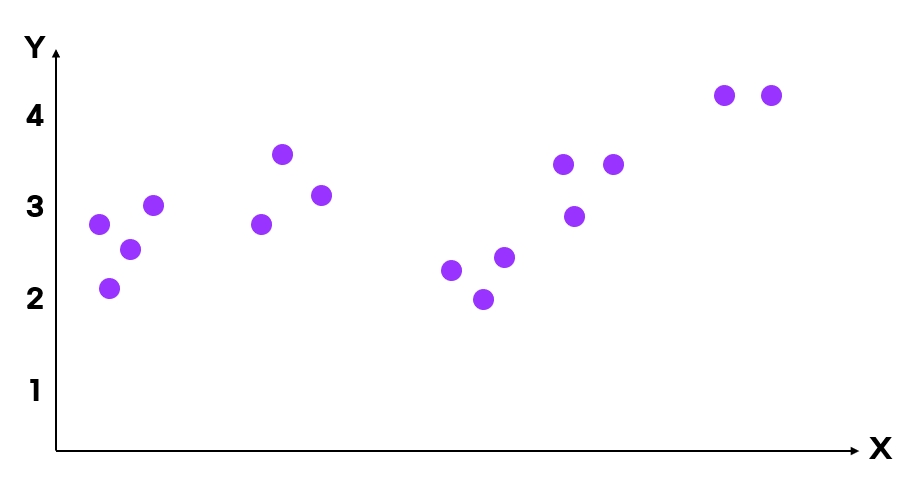
  * X값의 균일도를 반영한 지니 계수에 따라 분할 가능. 루트 도느를 split0기준으로, 다시 split1, 2를 기준으로 분할... 
  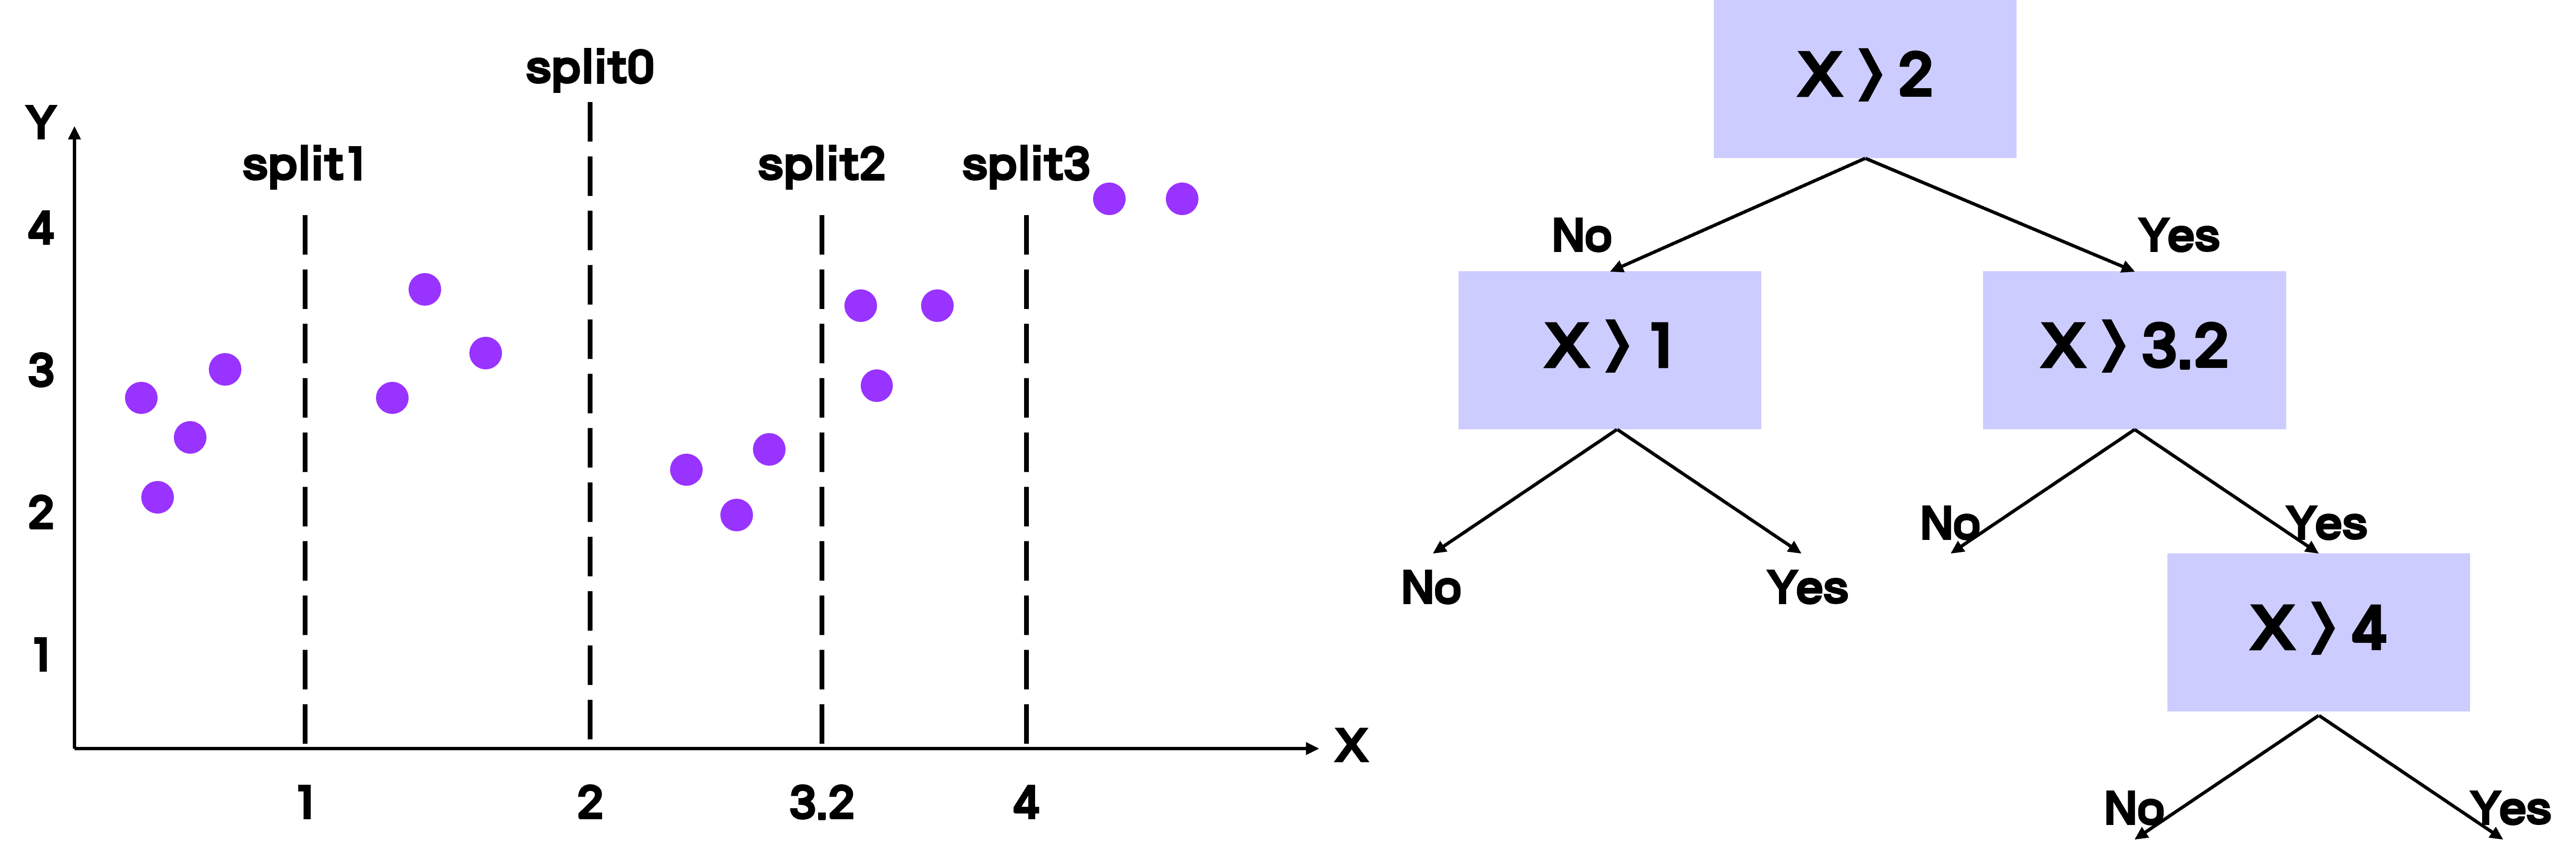
  * 리프 노드 생성 기준에 부합하는 트리 분할 완료 -> 리프 노드 소속된 데이터 값의 평균값 도출 -> 최종적으로 리프 노드에 결정값으로 할당
  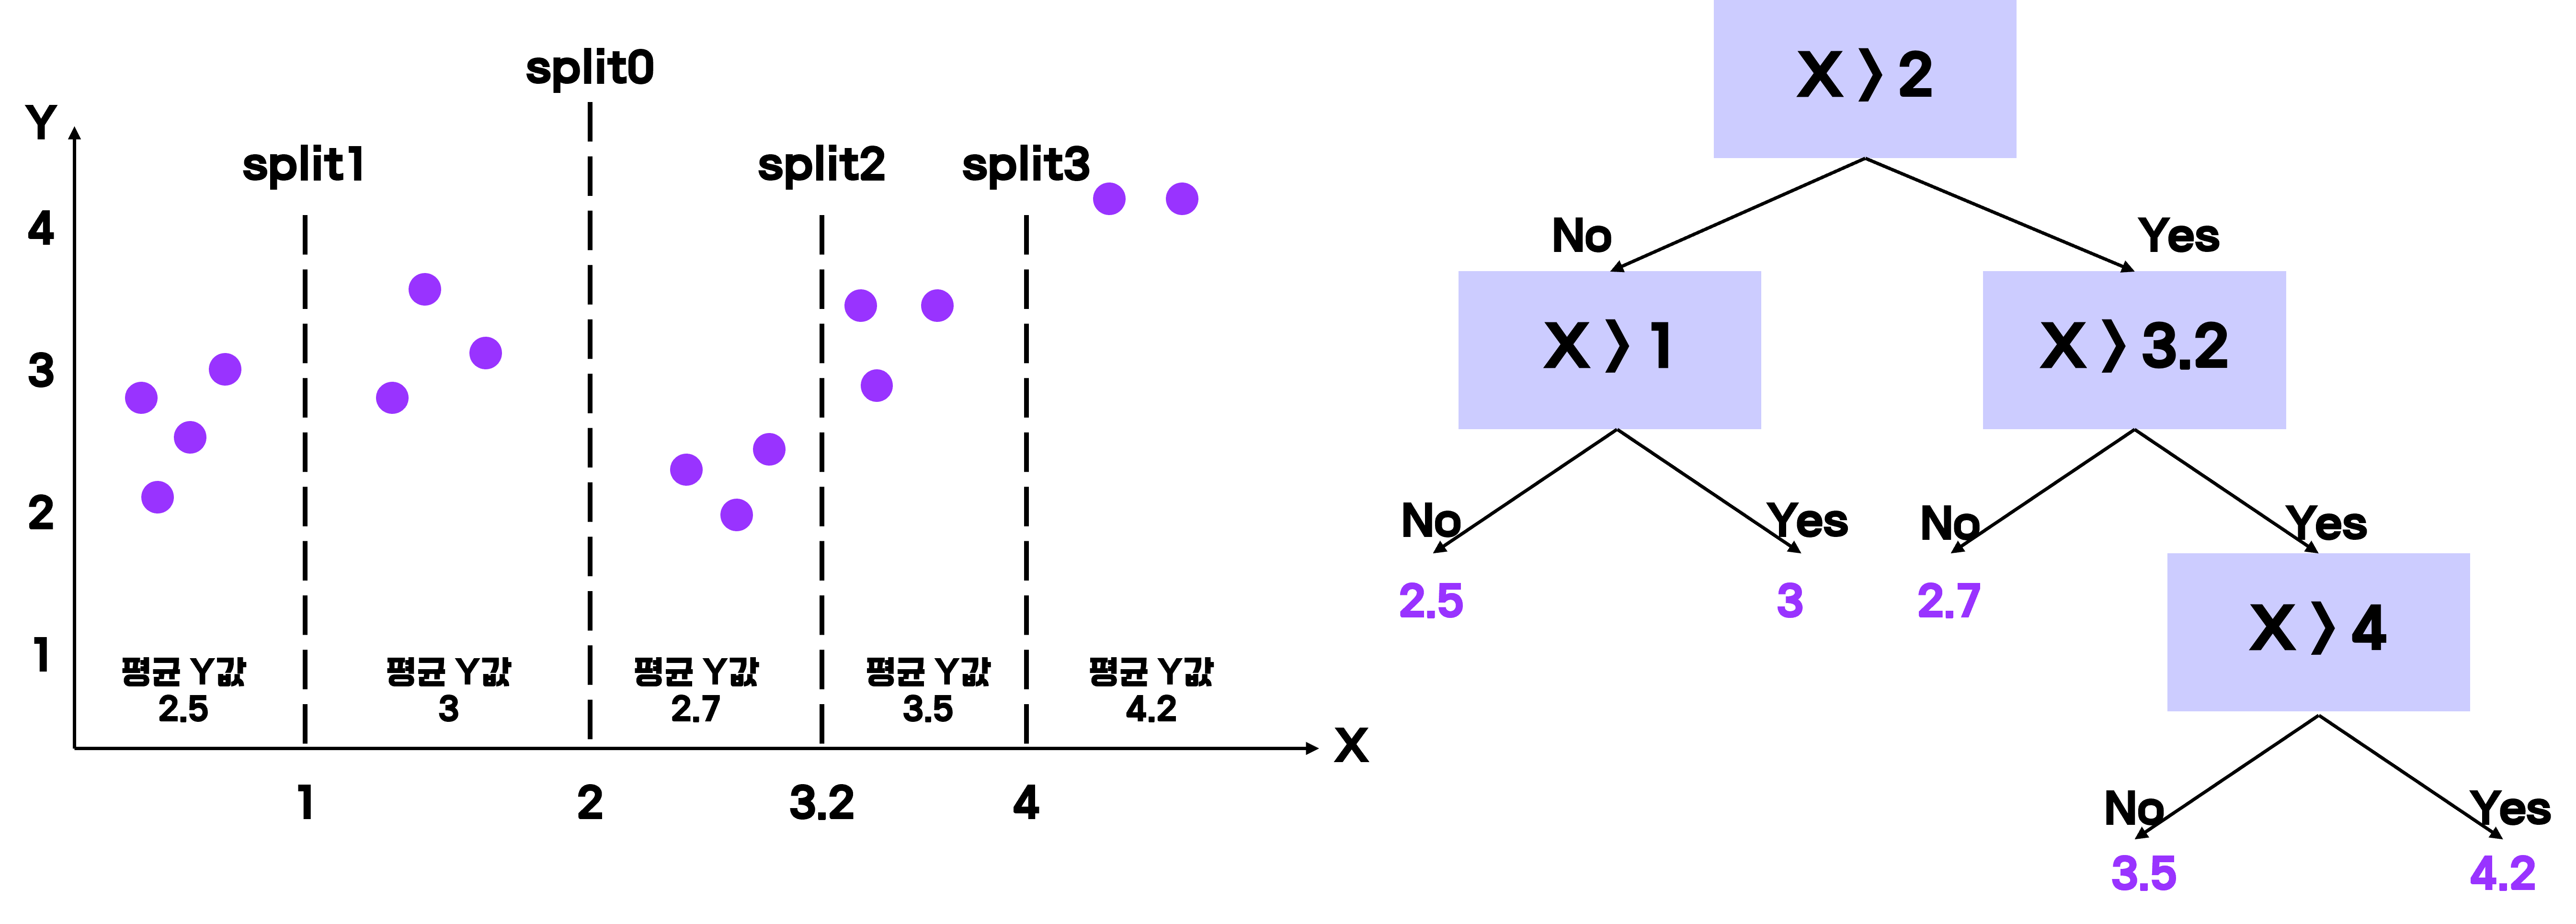
* 분류에 나온 모든 트리 기반 알고리즘(결정트리, 랜덤포레스트, GBM, XGBoost LightGBM)은 회귀도 가능 -> 트리 생성이 CART 알고리즘에 기반하므로
* 사이킷런 Estimator 클래스 : CART 기반의 회귀 수행할 수 있음
  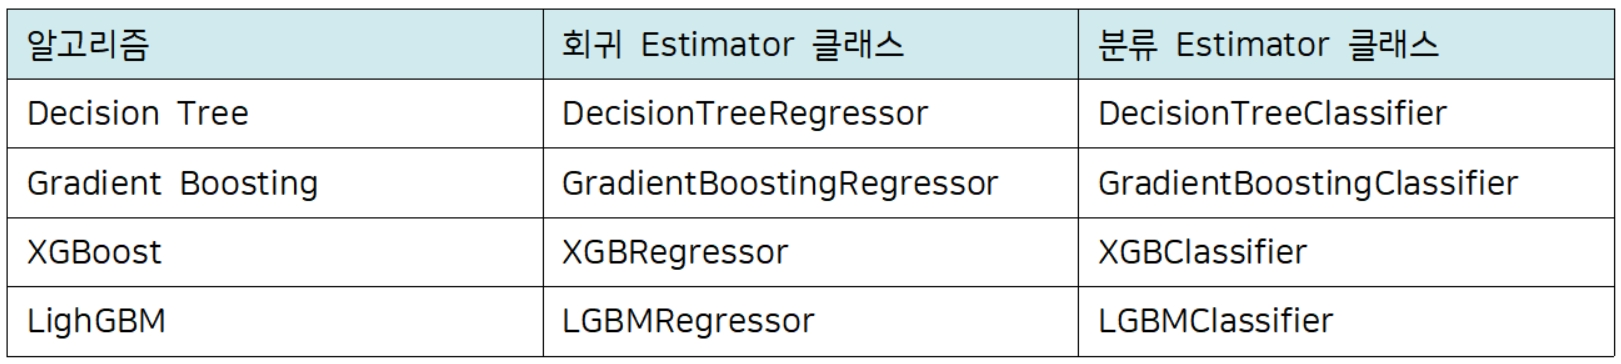
* 회귀 트리 Regressor 클래스
  * 선형 회귀와 다른 처리 방식임 => 회귀 계수를 제공하는 coef_ 속성 없음 -> 대신 feature_importances_로 피처별 중요도 앎
  * 하이퍼 파라미터는 분류 트리 Classifier의 하이퍼 파라미터와 거의 동일

# 랜덤 포레스트 회귀 트리 RandomForestRegressor 이용해 보스턴 주택 가격 예측

In [17]:
### 모듈 임포트
from sklearn.datasets import load_boston
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
boston = load_boston()
bostonDF = pd.DataFrame(boston.data, columns=boston.feature_names)
bostonDF['PRICE']=boston.target
y_target = bostonDF['PRICE']
x_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

### 랜덤 포레스트
rf=RandomForestRegressor(random_state=0, n_estimators=1000)
neg_mse_scores = cross_val_score(rf, x_data, y_target, scoring='neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(-1*neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print('5 교차 검증의 개별 Negative MSE scores : ', np.round(neg_mse_scores, 2))
print('5 교차 검증의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print('5 교차 검증의 평균 RMSE scores : {0:.3f}'.format(avg_rmse))

5 교차 검증의 개별 Negative MSE scores :  [ -7.88 -13.14 -20.57 -46.23 -18.88]
5 교차 검증의 개별 RMSE scores :  [2.81 3.63 4.54 6.8  4.34]
5 교차 검증의 평균 RMSE scores : 4.423


In [5]:
### 입력 모델과 데이터셋을 입력받아 교차 검증으로 평균 RMSE를 계산하는 함수

def get_model_cv_predict(model, x_data, y_target):
    neg_mse_scores = cross_val_score(rf, x_data, y_target, scoring='neg_mean_squared_error', cv=5)
    rmse_scores = np.sqrt(-1*neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)
    print('*** ', model.__class__.__name__, " ***")
    print('5 교차 검증의 평균 RMSE scores : {0:.3f}'.format(avg_rmse))

In [10]:
### 다양한 유형의 회귀 트리 대상 보스턴 주택 가격 예측

dt_reg = DecisionTreeRegressor(random_state=0, max_depth=4)
rf_reg = RandomForestRegressor(random_state=0, n_estimators=1000)
gb_reg = GradientBoostingRegressor(random_state=0, n_estimators=1000)
xgb_reg = XGBRegressor(n_estimators=1000)
lgb_reg = LGBMRegressor(n_estimators=1000)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:
    get_model_cv_predict(model, x_data, y_target)

***  DecisionTreeRegressor  ***
5 교차 검증의 평균 RMSE scores : 4.423
***  RandomForestRegressor  ***
5 교차 검증의 평균 RMSE scores : 4.423
***  GradientBoostingRegressor  ***
5 교차 검증의 평균 RMSE scores : 4.423
***  XGBRegressor  ***
5 교차 검증의 평균 RMSE scores : 4.423
***  LGBMRegressor  ***
5 교차 검증의 평균 RMSE scores : 4.423


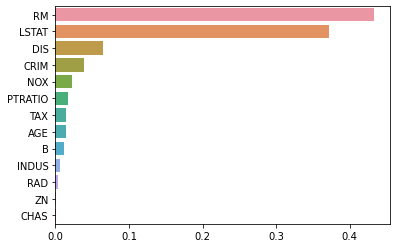

In [12]:
### 회귀 트리 Regressor 클래스 feature_importances_로 피처별 중요도 앎

rf_reg = RandomForestRegressor(n_estimators=1000)
rf_reg.fit(x_data, y_target)
feature_series = pd.Series(data=rf_reg.feature_importances_, index=x_data.columns)
feature_series = feature_series.sort_values(ascending=False)
sns.barplot(x=feature_series, y=feature_series.index)

(100, 2)


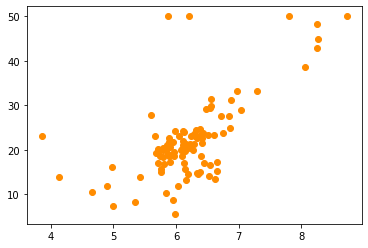

In [16]:
### 회귀 트리 Regressor의 예측값 판단하는지 선형 회귀와 비교해 시각화하기

bostonDF_sample = bostonDF[['RM', 'PRICE']]
bostonDF_sample = bostonDF_sample.sample(n=100, random_state=0)
print(bostonDF_sample.shape)
plt.figure()
plt.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c='darkorange')

In [18]:
# 결정트리 하이퍼 파라미터 max_depth 변화시켜가며 회귀 트리 예측선 변화 살펴보자
lr_reg = LinearRegression()
rf_reg2 = DecisionTreeRegressor(max_depth=2)
rf_reg7 = DecisionTreeRegressor(max_depth=7)

#실제 예측을 적용할 테스트용 데이터셋을 100개 데이터세트로 생성
x_test = np.arange(4.5, 8.5, 0.04).reshape(-1, 1)

# 2차원 평면 상에서 회귀 예측선 쉽게 표현하려 1개 변수만 추출
# 가장 큰 상관관계 가지는 RM 칼럼만 이용해 PRICE 예측 회귀선 표현할 것임
x_feature = bostonDF_sample['RM'].values.reshape(-1, 1)
y_target = bostonDF_sample['PRICE'].values.reshape(-1, 1)

lr_reg.fit(x_feature, y_target)
rf_reg2.fit(x_feature, y_target)
rf_reg7.fit(x_feature, y_target)

pred_lr = lr_reg.predict(x_test)
pred_rf2 = rf_reg2.predict(x_test)
pred_rf7 = rf_reg7.predict(x_test)

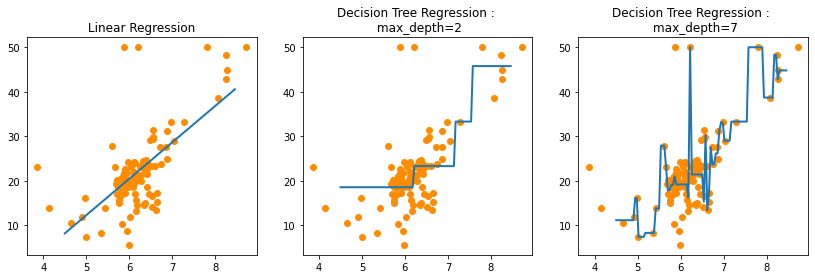

In [19]:
# 선형회귀와 결정트리 회귀의 max_depth 바꿔하며 학습한 Regressor에서 예측한 Price 회귀선 그리기

fig, (ax1, ax2, ax3) = plt.subplots(figsize=(14, 4), ncols=3)

ax1.set_title('Linear Regression')
ax1.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c='darkorange')
ax1.plot(x_test, pred_lr, label="linear", linewidth=2)

ax2.set_title('Decision Tree Regression : \n max_depth=2')
ax2.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c='darkorange')
ax2.plot(x_test, pred_rf2, label="max_depth=3", linewidth=2)

ax3.set_title('Decision Tree Regression : \n max_depth=7')
ax3.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c='darkorange')
ax3.plot(x_test, pred_rf7, label="max_depth=7", linewidth=2)

* 선형 회귀는 직선으로 예측 회귀선 표현
* 회귀 트리는 분할되는 데이터 지점에 따라 브랜치 만들며 계단 형태로 회귀선 표현
* max_depth=7인 경우, 학습 데이터의 이상치(outlier)데이터도 학습하며 복잡한 계단 형태의 회귀선 만듦 -> 과적합 되기 쉬운 모델 됨